## Track B - Synthetic Pair Recall Testing
#### eMPI Blocking Scheme Feasibility Assessment

Purpose:
* Empirically measure the recall of each blocking scheme against
    realistic data entry error patterns. We take real cleaned records,
    create perturbed copies that simulate specific error types, and
    test whether each blocking scheme catches the synthetic pairs.

Value:
* Track A measures structural properties of the blocking scheme
* Track B measures whether the scheme actually catches the kinds of true match pairs we care about - a blocking scheme could look great in Track A but may have hidden recall gaps for specific error patterns

Input Requirements:
* A pandas DataFrame called `df_clean` with the following columns
    produced by your team's production cleaning pipeline:
      - PATID
      - clean_LastNM, clean_FirstNM
      - clean_BirthDT
      - clean_SSN
      - clean_ZipCD
      - clean_Email
      - Consolidated_Phone_Array  (list column of cleaned phones per record)
 
    Phonetic encoding columns (dm_LastNM, soundex_LastNM, soundex_FirstNM)
    are NOT required as inputs — they are computed inline by this script
    since they are scoped to Phase 2 of the architecture and are not yet
    in the production cleaning pipeline.

OUTPUT:
    1. recall_matrix: per-scenario, per-block recall %
    2. CSV: track_b_recall_matrix.csv
    3. Visualization: track_b_recall_heatmap.png
    4. HTML report: track_b_recall_report.html
 
PASS/FAIL CRITERIA:
    - Cumulative recall (union of all 9 blocks) ≥ 95% for every scenario
    - Each individual block × scenario combination is informational
 
DEPENDENCIES (install once):
    pip install jellyfish phonetics
 
**HIPAA NOTE**:
    Synthetic perturbations operate on copies of real records but never
    print field values. All console output is aggregate statistics only.


In [1]:
import warnings
import random
from datetime import datetime
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# Phonetic encoding libraries — pure Python, no C++ compiler required
import jellyfish
import phonetics

import ast

 
warnings.filterwarnings("ignore")
 
# ── Reproducibility ─────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [2]:
# ── Input dataframe ─────────────────────────────────────────────────────────
# REPLACE THIS LINE WITH YOUR CLEANED DATAFRAME LOAD
df_clean = pd.read_parquet(r"C:\Users\Public\Documents\EMPI_latest\data\processed\MDM_Population_cleaned_v1_2026_05_24.parquet")
# For now, this assumes df_clean is already loaded in the notebook

TOTAL_RECORDS = len(df_clean)
print(f"✓ Cleaned dataset has {TOTAL_RECORDS:,} records")


✓ Cleaned dataset has 163,364 records


In [3]:
print("Columns in df_clean:")
for col in sorted(df_clean.columns.tolist()):
    print(f"  {col}")

Columns in df_clean:
  AddressLine1_clean
  AddressLine1_raw
  AddressLine2_clean
  AddressLine2_raw
  Address_normalized
  BirthDT_clean
  BirthDT_raw
  CityNM_clean
  CityNM_raw
  CountryNM
  Email_clean
  Email_raw
  FirstNM_clean
  FirstNM_raw
  LastNM_clean
  LastNM_raw
  MiddleNM_clean
  MiddleNM_raw
  PATID
  Phone01NBR_clean
  Phone01NBR_raw
  Phone02NBR_clean
  Phone02NBR_raw
  Phone03NBR_clean
  Phone03NBR_raw
  Phones_set
  PrimaryPhoneNBR_clean
  PrimaryPhoneNBR_raw
  SSN_clean
  SSN_raw
  SexAtBirthDSC_clean
  SexAtBirthDSC_raw
  StateCD_clean
  StateCD_raw
  SuffixNM_clean
  SuffixNM_raw
  ZipCD_clean_base
  ZipCD_clean_ext
  ZipCD_raw
  full_name_compact
  full_name_tokens
  last_4_SSN
  valid_record


In [4]:
# ── Column name mappings ─────────────────────────────────────────────────────
# Confirmed against df_clean column list — May 2026
COL_PATID         = "PATID"
COL_LAST_NM       = "LastNM_clean"
COL_FIRST_NM      = "FirstNM_clean"
COL_BIRTH_DT      = "BirthDT_clean"
COL_SSN           = "SSN_clean"
COL_ZIP           = "ZipCD_clean_base"
COL_EMAIL         = "Email_clean"
COL_PHONE_ARRAY   = "Phones_set"

# Phonetic encoding column names — computed inline, do not change
COL_DM_LASTNM     = "dm_LastNM"
COL_SX_LASTNM     = "soundex_LastNM"
COL_SX_FIRSTNM    = "soundex_FirstNM"
 
# ── Test parameters ─────────────────────────────────────────────────────────
N_ANCHOR_RECORDS = 1000        # records to sample as base for perturbation
PASS_THRESHOLD   = 95.0        # cumulative recall % threshold per scenario
 
# ── Phonetic encoding helpers ────────────────────────────────────────────────
# These MUST be byte-for-byte identical to what the production cleaning
# pipeline produces in Phase 2 (Pre-Computation & Feature Engineering).
# Any drift between feasibility-time and production-time phonetic encoding
# will invalidate Track B recall measurements.
 
def _safe_dm_primary(name):
    """
    Double Metaphone — returns primary code or NaN.
    Uses the `phonetics` library (pure Python, no compiler required).
    Returns the PRIMARY code only, consistent with the architecture spec.
    """
    if pd.isna(name) or not isinstance(name, str) or name.strip() == "":
        return np.nan
    try:
        result = phonetics.dmetaphone(name)
        return result[0] if result[0] else np.nan
    except Exception:
        return np.nan
 
def _safe_soundex(name):
    """Soundex — returns code or NaN. Uses jellyfish."""
    if pd.isna(name) or not isinstance(name, str) or name.strip() == "":
        return np.nan
    try:
        return jellyfish.soundex(name)
    except Exception:
        return np.nan

def _parse_phone_set(value):
    """
    Parse a string-serialized phone set back to a Python set of strings.

    Handles the following formats your pipeline may have produced:
      - "{'7735551234', '3125559876'}"  — set literal string
      - "['7735551234', '3125559876']"  — list literal string
      - "7735551234"                    — single phone as plain string
      - "{}"  or  "[]"  or  "nan"       — empty / null cases

    Returns a set of phone number strings, or an empty set if unparseable.
    """
    if pd.isna(value):
        return set()
    if isinstance(value, (set, list)):
        # Already the right type — normalize to set
        return set(str(p) for p in value if p and str(p).strip())
    if not isinstance(value, str):
        return set()

    value = value.strip()

    # Empty representations
    if value in ("", "nan", "None", "set()", "{}", "[]"):
        return set()

    # Try ast.literal_eval first — handles both set and list literal strings
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, (set, list, tuple)):
            return set(str(p).strip() for p in parsed if str(p).strip())
        if isinstance(parsed, str):
            return {parsed.strip()} if parsed.strip() else set()
    except (ValueError, SyntaxError):
        pass

    # Fallback: strip braces/brackets and split by comma
    # Handles edge cases where ast.literal_eval fails on malformed strings
    try:
        cleaned = value.strip("{}[]").replace("'", "").replace('"', "")
        phones  = {p.strip() for p in cleaned.split(",") if p.strip()}
        return phones
    except Exception:
        return set()

 
TOTAL_RECORDS = len(df_clean)
print(f"✓ Track B Recall Testing starting")
print(f"✓ Cleaned dataset: {TOTAL_RECORDS:,} records")
print(f"✓ Sampling {N_ANCHOR_RECORDS:,} anchor records for perturbation")
print(f"✓ Pass threshold: ≥{PASS_THRESHOLD}% cumulative recall per scenario\n")

✓ Track B Recall Testing starting
✓ Cleaned dataset: 163,364 records
✓ Sampling 1,000 anchor records for perturbation
✓ Pass threshold: ≥95.0% cumulative recall per scenario



## Cell 2: Compute Phonetic Encoding Columns on df_clean

* The production cleaning pipeline produces clean_* demographic columns but does NOT compute phonetic encodings — those are scoped to Phase 2 of the solution architecture. We compute them inline here so the blocking key definitions work end-to-end for the feasibility assessment.

In [5]:
print("── Computing phonetic encoding columns on cleaned dataset ──────────")
 
print("  Computing Double Metaphone on clean_LastNM... (30–60 sec)")
df_clean[COL_DM_LASTNM] = df_clean[COL_LAST_NM].apply(_safe_dm_primary)
print(f"    ✓ {COL_DM_LASTNM} computed "
      f"({df_clean[COL_DM_LASTNM].notna().sum():,} non-null values)")
 
print("  Computing Soundex on clean_LastNM...")
df_clean[COL_SX_LASTNM] = df_clean[COL_LAST_NM].apply(_safe_soundex)
print(f"    ✓ {COL_SX_LASTNM} computed "
      f"({df_clean[COL_SX_LASTNM].notna().sum():,} non-null values)")
 
print("  Computing Soundex on clean_FirstNM...")
df_clean[COL_SX_FIRSTNM] = df_clean[COL_FIRST_NM].apply(_safe_soundex)
print(f"    ✓ {COL_SX_FIRSTNM} computed "
      f"({df_clean[COL_SX_FIRSTNM].notna().sum():,} non-null values)")
 
print("\n✓ Phonetic columns ready on df_clean\n")
 

── Computing phonetic encoding columns on cleaned dataset ──────────
  Computing Double Metaphone on clean_LastNM... (30–60 sec)
    ✓ dm_LastNM computed (162,835 non-null values)
  Computing Soundex on clean_LastNM...
    ✓ soundex_LastNM computed (162,837 non-null values)
  Computing Soundex on clean_FirstNM...
    ✓ soundex_FirstNM computed (162,166 non-null values)

✓ Phonetic columns ready on df_clean



## Cell 3 - Sample High Quality Anchor Records
* We need records with the best possible field coverage to ensure that each perturbation scenario has the fields available to perturb

In [6]:
print("── Sampling high-quality anchor records ────────────────────────────")

# ── Step 1: Parse Phones_set strings into real Python sets ──────────────────
print("  Parsing Phones_set strings to Python sets...")
df_clean["_phones_parsed"] = df_clean[COL_PHONE_ARRAY].apply(_parse_phone_set)
n_with_phones = (df_clean["_phones_parsed"].apply(len) > 0).sum()
print(f"  Records with ≥1 parsed phone: {n_with_phones:,} "
      f"({100 * n_with_phones / len(df_clean):.1f}%)\n")

# ── Helper: check if parsed phone set is non-empty ──────────────────────────
def _has_phones(x):
    return isinstance(x, set) and len(x) > 0

# ── Helper: check if BirthDT_clean is a parseable non-null date ─────────────
def _has_valid_dob(x):
    if pd.isna(x):
        return False
    try:
        return not pd.isna(pd.to_datetime(x, errors="coerce"))
    except Exception:
        return False

# ── Tier 1: Strict — all fields present ─────────────────────────────────────
strict_mask = (
    df_clean[COL_LAST_NM].notna() &
    df_clean[COL_FIRST_NM].notna() &
    df_clean[COL_BIRTH_DT].apply(_has_valid_dob) &
    df_clean[COL_SSN].notna() &
    df_clean[COL_ZIP].notna() &
    df_clean[COL_EMAIL].notna() &
    df_clean["_phones_parsed"].apply(_has_phones)
)
strict_pool = df_clean[strict_mask].copy()
print(f"  Tier 1 (all fields):          {len(strict_pool):>7,} records")

# ── Tier 2: Relaxed — drop SSN and Email (sparse fields) ────────────────────
# SSN covers 21%, Email 31%. Requiring both alongside all other fields
# collapses the pool. Records without SSN/Email still contribute valid
# pairs for name, DOB, ZIP, and phone perturbation scenarios.
relaxed_mask = (
    df_clean[COL_LAST_NM].notna() &
    df_clean[COL_FIRST_NM].notna() &
    df_clean[COL_BIRTH_DT].apply(_has_valid_dob) &
    df_clean[COL_ZIP].notna() &
    df_clean["_phones_parsed"].apply(_has_phones)
)
relaxed_pool = df_clean[relaxed_mask].copy()
print(f"  Tier 2 (no SSN/Email req):    {len(relaxed_pool):>7,} records")

# ── Tier 3: Minimal — name and DOB only ─────────────────────────────────────
minimal_mask = (
    df_clean[COL_LAST_NM].notna() &
    df_clean[COL_FIRST_NM].notna() &
    df_clean[COL_BIRTH_DT].apply(_has_valid_dob)
)
minimal_pool = df_clean[minimal_mask].copy()
print(f"  Tier 3 (name + DOB only):     {len(minimal_pool):>7,} records")

# ── Select the best available pool ──────────────────────────────────────────
if len(strict_pool) >= 100:
    selected_pool = strict_pool
    pool_label    = "Tier 1 (strict — all fields)"
elif len(relaxed_pool) >= 100:
    selected_pool = relaxed_pool
    pool_label    = "Tier 2 (relaxed — no SSN/Email requirement)"
    print(f"\n  ⚠️  Strict pool too small. Using Tier 2.")
    print(f"     SSN and Email perturbation scenarios will have fewer")
    print(f"     successful pairs — handled by n_failed counter.")
elif len(minimal_pool) >= 100:
    selected_pool = minimal_pool
    pool_label    = "Tier 3 (minimal — name + DOB only)"
    print(f"\n  ⚠️  Relaxed pool too small. Using Tier 3.")
else:
    raise ValueError(
        f"No viable anchor pool found after parsing Phones_set.\n"
        f"Strict: {len(strict_pool)} | Relaxed: {len(relaxed_pool)} | "
        f"Minimal: {len(minimal_pool)}\n"
        f"Check that _parse_phone_set() is handling your specific "
        f"Phones_set string format correctly."
    )

print(f"\n  Selected pool: {pool_label}")
print(f"  Pool size:     {len(selected_pool):,} records")

# ── Sample from the selected pool ───────────────────────────────────────────
if len(selected_pool) < N_ANCHOR_RECORDS:
    print(f"\n  ⚠️  Pool ({len(selected_pool):,}) smaller than requested "
          f"anchor count ({N_ANCHOR_RECORDS:,}).")
    print(f"     Using all {len(selected_pool):,} records as anchors.")
    anchors = selected_pool.copy()
else:
    anchors = selected_pool.sample(
        n=N_ANCHOR_RECORDS, random_state=RANDOM_SEED
    ).copy()
    print(f"  Sampled:       {len(anchors):,} anchor records")

# ── Reset index and tag anchors ──────────────────────────────────────────────
anchors = anchors.reset_index(drop=True)
anchors["_anchor_idx"] = range(len(anchors))

# ── Field availability summary within selected anchors ───────────────────────
print(f"\n  Field availability within selected anchors:")
check_fields = {
    COL_LAST_NM:          "LastNM_clean",
    COL_FIRST_NM:         "FirstNM_clean",
    COL_BIRTH_DT:         "BirthDT_clean",
    COL_SSN:              "SSN_clean",
    COL_ZIP:              "ZipCD_clean_base",
    COL_EMAIL:            "Email_clean",
    "_phones_parsed":     "Phones_set (parsed)",
}
for col, label in check_fields.items():
    if col == "_phones_parsed":
        n = anchors[col].apply(_has_phones).sum()
    else:
        n = anchors[col].notna().sum()
    pct = 100 * n / len(anchors)
    print(f"    {label:<25}: {n:>5,} / {len(anchors):,} ({pct:.1f}%)")

print()
 

── Sampling high-quality anchor records ────────────────────────────
  Parsing Phones_set strings to Python sets...
  Records with ≥1 parsed phone: 154,232 (94.4%)

  Tier 1 (all fields):           11,536 records
  Tier 2 (no SSN/Email req):    152,295 records
  Tier 3 (name + DOB only):     162,025 records

  Selected pool: Tier 1 (strict — all fields)
  Pool size:     11,536 records
  Sampled:       1,000 anchor records

  Field availability within selected anchors:
    LastNM_clean             : 1,000 / 1,000 (100.0%)
    FirstNM_clean            : 1,000 / 1,000 (100.0%)
    BirthDT_clean            : 1,000 / 1,000 (100.0%)
    SSN_clean                : 1,000 / 1,000 (100.0%)
    ZipCD_clean_base         : 1,000 / 1,000 (100.0%)
    Email_clean              : 1,000 / 1,000 (100.0%)
    Phones_set (parsed)      : 1,000 / 1,000 (100.0%)



In [7]:
# ── Diagnostic: identify which fields are blocking anchor selection ──────────
print("── Anchor Pool Diagnostic ──────────────────────────────────────────")
print(f"  Total records in df_clean: {len(df_clean):,}\n")

# Check each field individually
fields_to_check = {
    "LastNM_clean non-null":    df_clean[COL_LAST_NM].notna(),
    "FirstNM_clean non-null":   df_clean[COL_FIRST_NM].notna(),
    "BirthDT_clean non-null":   df_clean[COL_BIRTH_DT].notna(),
    "SSN_clean non-null":       df_clean[COL_SSN].notna(),
    "ZipCD_clean_base non-null":df_clean[COL_ZIP].notna(),
    "Email_clean non-null":     df_clean[COL_EMAIL].notna(),
}

for label, mask in fields_to_check.items():
    count = mask.sum()
    pct   = 100 * count / len(df_clean)
    print(f"  {label:<30}: {count:>7,} records ({pct:.1f}%)")

# Check Phones_set separately — inspect actual types present
print(f"\n  Phones_set type distribution (first 10 non-null values):")
phone_types = df_clean[COL_PHONE_ARRAY].dropna().apply(type).value_counts()
print(phone_types.to_string())

# Check how many records have a non-empty Phones_set regardless of type
n_list_nonempty = df_clean[COL_PHONE_ARRAY].apply(
    lambda x: isinstance(x, list) and len(x) > 0
).sum()
n_set_nonempty = df_clean[COL_PHONE_ARRAY].apply(
    lambda x: isinstance(x, set) and len(x) > 0
).sum()
n_either_nonempty = df_clean[COL_PHONE_ARRAY].apply(
    lambda x: isinstance(x, (list, set)) and len(x) > 0
).sum()

print(f"\n  Records with non-empty list:        {n_list_nonempty:>7,}")
print(f"  Records with non-empty set:         {n_set_nonempty:>7,}")
print(f"  Records with non-empty list or set: {n_either_nonempty:>7,}")

# Show cumulative mask — how many survive each additional filter
print(f"\n  Cumulative mask (each filter added):")
cumulative = pd.Series([True] * len(df_clean))
for label, mask in fields_to_check.items():
    cumulative = cumulative & mask
    print(f"  After {label:<30}: {cumulative.sum():>7,} records remaining")

# Add phone check both ways
cumulative_list = cumulative & df_clean[COL_PHONE_ARRAY].apply(
    lambda x: isinstance(x, list) and len(x) > 0
)
cumulative_set = cumulative & df_clean[COL_PHONE_ARRAY].apply(
    lambda x: isinstance(x, (list, set)) and len(x) > 0
)
print(f"  After phone non-empty (list only):  {cumulative_list.sum():>7,} records remaining")
print(f"  After phone non-empty (list/set):   {cumulative_set.sum():>7,} records remaining")

── Anchor Pool Diagnostic ──────────────────────────────────────────
  Total records in df_clean: 163,364

  LastNM_clean non-null         : 162,837 records (99.7%)
  FirstNM_clean non-null        : 162,166 records (99.3%)
  BirthDT_clean non-null        : 162,894 records (99.7%)
  SSN_clean non-null            :  34,916 records (21.4%)
  ZipCD_clean_base non-null     : 158,762 records (97.2%)
  Email_clean non-null          :  50,865 records (31.1%)

  Phones_set type distribution (first 10 non-null values):
Phones_set
<class 'str'>    163364

  Records with non-empty list:              0
  Records with non-empty set:               0
  Records with non-empty list or set:       0

  Cumulative mask (each filter added):
  After LastNM_clean non-null         : 162,837 records remaining
  After FirstNM_clean non-null        : 162,143 records remaining
  After BirthDT_clean non-null        : 162,025 records remaining
  After SSN_clean non-null            :  34,910 records remaining
  After

## Cell 4 - Perturbation Functions
* Each function takes an anchor record (as a pandas Series) and returns a perturbed copy representing a specific error scenario

In [8]:
def perturb_lastnm_typo(row):
    """Swap two adjacent characters in clean_LastNM."""
    new_row = row.copy()
    ln = str(row[COL_LAST_NM])
    if len(ln) < 3:
        return None
    pos = random.randint(0, len(ln) - 2)
    new_ln = ln[:pos] + ln[pos+1] + ln[pos] + ln[pos+2:]
    new_row[COL_LAST_NM] = new_ln
    # Recompute phonetic codes for the perturbed last name
    new_row[COL_DM_LASTNM] = _safe_dm_primary(new_ln)
    new_row[COL_SX_LASTNM] = _safe_soundex(new_ln)
    return new_row
 
def perturb_lastnm_phonetic(row):
    """Replace one character with a phonetic equivalent (S↔Z, C↔K, etc.)."""
    new_row = row.copy()
    ln = str(row[COL_LAST_NM])
    if len(ln) < 2:
        return None
    swaps = {"S": "Z", "Z": "S", "C": "K", "K": "C",
             "F": "PH", "PH": "F", "I": "Y", "Y": "I"}
    for old, new in swaps.items():
        if old in ln:
            new_ln = ln.replace(old, new, 1)
            new_row[COL_LAST_NM] = new_ln
            new_row[COL_DM_LASTNM] = _safe_dm_primary(new_ln)
            new_row[COL_SX_LASTNM] = _safe_soundex(new_ln)
            return new_row
    return None
 
def perturb_firstnm_phonetic(row):
    """Phonetic variant of clean_FirstNM."""
    new_row = row.copy()
    fn = str(row[COL_FIRST_NM])
    if len(fn) < 2:
        return None
    swaps = {"K": "C", "C": "K", "S": "Z", "I": "Y", "Y": "I"}
    for old, new in swaps.items():
        if old in fn:
            new_fn = fn.replace(old, new, 1)
            new_row[COL_FIRST_NM] = new_fn
            new_row[COL_SX_FIRSTNM] = _safe_soundex(new_fn)
            return new_row
    return None
 
def perturb_firstnm_nickname(row):
    """
    Replace clean_FirstNM with a nickname approximation (truncate to 4 chars).
    Simulates MICHAEL vs MIKE, KATHERINE vs KATE, etc.
    """
    new_row = row.copy()
    fn = str(row[COL_FIRST_NM])
    if len(fn) < 5:
        return None
    new_fn = fn[:4]
    new_row[COL_FIRST_NM] = new_fn
    new_row[COL_SX_FIRSTNM] = _safe_soundex(new_fn)
    return new_row
 
def perturb_dob_transposition(row):
    """Swap birth month and day. Returns None if month==day or invalid."""
    new_row = row.copy()
    dob = pd.to_datetime(row[COL_BIRTH_DT], errors="coerce")
    if pd.isna(dob) or dob.month == dob.day:
        return None
    try:
        new_dob = pd.Timestamp(year=dob.year, month=dob.day, day=dob.month)
        new_row[COL_BIRTH_DT] = new_dob
        return new_row
    except (ValueError, TypeError):
        return None  # invalid (e.g. day=31 in a month with <31 days)
 
def perturb_dob_partial_loss(row):
    """Null out birth month and day, leaving year. Often stored as Jan-01."""
    new_row = row.copy()
    dob = pd.to_datetime(row[COL_BIRTH_DT], errors="coerce")
    if pd.isna(dob):
        return None
    new_row[COL_BIRTH_DT] = pd.Timestamp(year=dob.year, month=1, day=1)
    return new_row
 
def perturb_ssn_typo(row):
    """Single-digit error in first 5 digits of SSN. Last 4 remain intact."""
    new_row = row.copy()
    ssn = str(row[COL_SSN])
    if len(ssn) != 9:
        return None
    pos = random.randint(0, 4)
    original_digit = ssn[pos]
    new_digit = random.choice([d for d in "0123456789" if d != original_digit])
    new_ssn = ssn[:pos] + new_digit + ssn[pos+1:]
    new_row[COL_SSN] = new_ssn
    return new_row
 
def perturb_ssn_null(row):
    """Null out SSN entirely. Inconsistent SSN population across systems."""
    new_row = row.copy()
    new_row[COL_SSN] = np.nan
    return new_row
 
def perturb_phone_reorder(row):
    """
    Same number, different conceptual column position.
    Since clean_phone_array consolidates all four phone columns into a set,
    the perturbation is a no-op on the array itself. B5 should achieve 100%
    recall on this scenario — if it does not, there is a bug in phone
    consolidation worth investigating.
    """
    new_row = row.copy()
    return new_row
 
def perturb_address_zip_change(row):
    """Change the ZIP code (simulates a patient moving)."""
    new_row = row.copy()
    old_zip = str(row[COL_ZIP])
    if len(old_zip) != 5:
        return None
    new_zip = str((int(old_zip[0]) + 1) % 10) + old_zip[1:]
    new_row[COL_ZIP] = new_zip
    return new_row
 
 
# Map perturbation name to its function and description
PERTURBATIONS = {
    "lastnm_typo":        ("Last name typo (adjacent char swap)",
                            perturb_lastnm_typo),
    "lastnm_phonetic":    ("Last name phonetic variant (S↔Z, C↔K)",
                            perturb_lastnm_phonetic),
    "firstnm_phonetic":   ("First name phonetic variant",
                            perturb_firstnm_phonetic),
    "firstnm_nickname":   ("First name nickname (truncated form)",
                            perturb_firstnm_nickname),
    "dob_transposition":  ("DOB month/day transposition",
                            perturb_dob_transposition),
    "dob_partial_loss":   ("DOB partial loss (year only retained)",
                            perturb_dob_partial_loss),
    "ssn_typo":           ("SSN single-digit typo in first 5 digits",
                            perturb_ssn_typo),
    "ssn_null":           ("SSN missing in one record",
                            perturb_ssn_null),
    "phone_reorder":      ("Phone reordering (same number, different col)",
                            perturb_phone_reorder),
    "address_zip_change": ("Address change (different ZIP)",
                            perturb_address_zip_change),
}
 
print(f"✓ Loaded {len(PERTURBATIONS)} perturbation scenarios\n")
 

✓ Loaded 10 perturbation scenarios



## Cell 5 - Generate Synthetic Pair Dataset

In [9]:
print("── Generating synthetic perturbed records ──────────────────────────")
 
synthetic_records = []
synthetic_pairs   = []   # list of (anchor_PATID, perturbed_PATID, scenario)
 
for scenario_name, (description, perturb_fn) in PERTURBATIONS.items():
    n_success = 0
    n_failed  = 0
 
    for _, anchor_row in anchors.iterrows():
        perturbed = perturb_fn(anchor_row)
        if perturbed is None:
            n_failed += 1
            continue
 
        # Assign a new synthetic PATID for the perturbed record
        new_patid = f"SYNTH_{scenario_name}_{anchor_row['_anchor_idx']:05d}"
        perturbed[COL_PATID]     = new_patid
        perturbed["_perturbation"]   = scenario_name
        perturbed["_anchor_patid"]   = anchor_row[COL_PATID]
 
        synthetic_records.append(perturbed)
        synthetic_pairs.append({
            "anchor_patid":    anchor_row[COL_PATID],
            "perturbed_patid": new_patid,
            "scenario":        scenario_name,
            "scenario_desc":   description,
        })
        n_success += 1
 
    print(f"  {scenario_name:<22}: {n_success:>5} pairs generated, "
          f"{n_failed:>3} skipped (insufficient fields)")
 
synthetic_df       = pd.DataFrame(synthetic_records)
synthetic_pairs_df = pd.DataFrame(synthetic_pairs)
print(f"\n  Total synthetic match pairs: {len(synthetic_pairs_df):,}\n")
 
 

── Generating synthetic perturbed records ──────────────────────────
  lastnm_typo           :   998 pairs generated,   2 skipped (insufficient fields)
  lastnm_phonetic       :   828 pairs generated, 172 skipped (insufficient fields)
  firstnm_phonetic      :   781 pairs generated, 219 skipped (insufficient fields)
  firstnm_nickname      :   881 pairs generated, 119 skipped (insufficient fields)
  dob_transposition     :   346 pairs generated, 654 skipped (insufficient fields)
  dob_partial_loss      :  1000 pairs generated,   0 skipped (insufficient fields)
  ssn_typo              :  1000 pairs generated,   0 skipped (insufficient fields)
  ssn_null              :  1000 pairs generated,   0 skipped (insufficient fields)
  phone_reorder         :  1000 pairs generated,   0 skipped (insufficient fields)
  address_zip_change    :  1000 pairs generated,   0 skipped (insufficient fields)

  Total synthetic match pairs: 8,834



## Cell 6 - Augment Dataset and Generate Blocking Keys

In [10]:
print("── Building augmented dataset with synthetic pairs ──────────────────")
 
augmented = pd.concat([df_clean, synthetic_df], ignore_index=True)
print(f"  Total records in augmented dataset: {len(augmented):,}")
print(f"  Original records: {len(df_clean):,}")
print(f"  Synthetic records: {len(synthetic_df):,}\n")
 
print("  Computing blocking key columns on augmented dataset...")
 
augmented["_dob_str"] = pd.to_datetime(
    augmented[COL_BIRTH_DT], errors="coerce"
).dt.strftime("%Y-%m-%d")
augmented["_birth_year"] = pd.to_datetime(
    augmented[COL_BIRTH_DT], errors="coerce"
).dt.year.astype("Int64")
augmented["_fn_prefix3"] = augmented[COL_FIRST_NM].str[:3]
augmented["_ssn_last4"] = np.where(
    augmented[COL_SSN].notna(),
    augmented[COL_SSN].astype(str).str[-4:],
    np.nan
)
 
print("  ✓ Derived columns computed\n")
 

── Building augmented dataset with synthetic pairs ──────────────────
  Total records in augmented dataset: 172,198
  Original records: 163,364
  Synthetic records: 8,834

  Computing blocking key columns on augmented dataset...
  ✓ Derived columns computed



## Cell 7 - Build Block Key Columns on Augmented Dataset

In [11]:
print("── Computing blocking key values for each block ─────────────────────")
 
augmented["_bk_b1"] = augmented[COL_SSN]
 
augmented["_bk_b2"] = np.where(
    augmented[COL_LAST_NM].notna() & augmented["_dob_str"].notna(),
    augmented[COL_LAST_NM].astype(str) + "|" + augmented["_dob_str"],
    np.nan
)
 
augmented["_bk_b3"] = np.where(
    augmented[COL_DM_LASTNM].notna() & augmented["_dob_str"].notna(),
    augmented[COL_DM_LASTNM].astype(str) + "|" + augmented["_dob_str"],
    np.nan
)
 
augmented["_bk_b4"] = np.where(
    (augmented[COL_LAST_NM].notna() & augmented["_birth_year"].notna()
     & augmented["_fn_prefix3"].notna()),
    (augmented[COL_LAST_NM].astype(str) + "|" +
     augmented["_birth_year"].astype(str) + "|" +
     augmented["_fn_prefix3"].astype(str)),
    np.nan
)
 
augmented["_bk_b6"] = augmented[COL_EMAIL]
 
augmented["_bk_b7"] = np.where(
    (augmented[COL_DM_LASTNM].notna() & augmented[COL_ZIP].notna()
     & augmented["_birth_year"].notna()),
    (augmented[COL_DM_LASTNM].astype(str) + "|" +
     augmented[COL_ZIP].astype(str) + "|" +
     augmented["_birth_year"].astype(str)),
    np.nan
)
 
augmented["_bk_b8"] = np.where(
    (augmented[COL_SX_FIRSTNM].notna() & augmented[COL_SX_LASTNM].notna()
     & augmented["_birth_year"].notna()),
    (augmented[COL_SX_FIRSTNM].astype(str) + "|" +
     augmented[COL_SX_LASTNM].astype(str) + "|" +
     augmented["_birth_year"].astype(str)),
    np.nan
)
 
augmented["_bk_b9"] = np.where(
    (augmented[COL_LAST_NM].notna() & augmented[COL_FIRST_NM].notna()
     & augmented["_ssn_last4"].notna()),
    (augmented[COL_LAST_NM].astype(str) + "|" +
     augmented[COL_FIRST_NM].astype(str) + "|" +
     augmented["_ssn_last4"].astype(str)),
    np.nan
)
 
print("  ✓ Block keys B1, B2, B3, B4, B6, B7, B8, B9 computed")
 
print("  Building B5 phone lookup (parsing Phones_set strings)...")
augmented["_phones_parsed"] = augmented[COL_PHONE_ARRAY].apply(_parse_phone_set)
patid_phones = (
    augmented[augmented["_phones_parsed"].apply(len) > 0]
    .set_index(COL_PATID)["_phones_parsed"]
    .to_dict()
)
print(f"  ✓ B5 phone lookup built "
      f"({len(patid_phones):,} records with ≥1 phone)\n")
 

── Computing blocking key values for each block ─────────────────────
  ✓ Block keys B1, B2, B3, B4, B6, B7, B8, B9 computed
  Building B5 phone lookup (parsing Phones_set strings)...
  ✓ B5 phone lookup built (163,066 records with ≥1 phone)



## Cell 8 - Compute Recall Scenario per Block

In [12]:
print("── Computing recall per scenario per block ─────────────────────────")
print("  Iterating through synthetic pairs — may take a few minutes...\n")
 
block_ids   = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B9"]
recall_data = []
 
# Build a fast lookup of {PATID -> blocking key} per block for performance
patid_blocks = {}
for block_id in ["B1", "B2", "B3", "B4", "B6", "B7", "B8", "B9"]:
    col = f"_bk_{block_id.lower()}"
    key_lookup = augmented[[COL_PATID, col]].dropna(subset=[col])
    patid_blocks[block_id] = dict(zip(key_lookup[COL_PATID], key_lookup[col]))
 
for scenario_name, (description, _) in PERTURBATIONS.items():
    scenario_pairs = synthetic_pairs_df[
        synthetic_pairs_df["scenario"] == scenario_name
    ]
    n_pairs = len(scenario_pairs)
    if n_pairs == 0:
        continue
 
    captures        = {b: 0 for b in block_ids}
    union_capture   = 0
 
    for _, pair in scenario_pairs.iterrows():
        anchor_id        = pair["anchor_patid"]
        perturbed_id     = pair["perturbed_patid"]
        any_block_caught = False
 
        # Check each non-B5 block via the fast lookup
        for block_id in ["B1", "B2", "B3", "B4", "B6", "B7", "B8", "B9"]:
            a_key = patid_blocks[block_id].get(anchor_id)
            b_key = patid_blocks[block_id].get(perturbed_id)
            if a_key is not None and b_key is not None and a_key == b_key:
                captures[block_id] += 1
                any_block_caught = True
 
        # B5 — phone set intersection
        a_phones = patid_phones.get(anchor_id, set())
        b_phones = patid_phones.get(perturbed_id, set())
        if a_phones & b_phones:
            captures["B5"] += 1
            any_block_caught = True
 
        if any_block_caught:
            union_capture += 1
 
    row = {"scenario": scenario_name, "description": description,
           "n_pairs": n_pairs}
    for block_id in block_ids:
        row[f"recall_{block_id}"] = 100 * captures[block_id] / n_pairs
    row["cumulative_recall"] = 100 * union_capture / n_pairs
    recall_data.append(row)
 
    print(f"  {scenario_name:<22}: cumulative recall = "
          f"{row['cumulative_recall']:>5.1f}% "
          f"({union_capture}/{n_pairs})")
 
recall_matrix = pd.DataFrame(recall_data)
recall_matrix.to_csv("track_b_recall_matrix.csv", index=False)
print("\n  ✓ Recall matrix exported: track_b_recall_matrix.csv\n")
 

── Computing recall per scenario per block ─────────────────────────
  Iterating through synthetic pairs — may take a few minutes...

  lastnm_typo           : cumulative recall = 100.0% (998/998)
  lastnm_phonetic       : cumulative recall = 100.0% (828/828)
  firstnm_phonetic      : cumulative recall = 100.0% (781/781)
  firstnm_nickname      : cumulative recall = 100.0% (881/881)
  dob_transposition     : cumulative recall = 100.0% (346/346)
  dob_partial_loss      : cumulative recall = 100.0% (1000/1000)
  ssn_typo              : cumulative recall = 100.0% (1000/1000)
  ssn_null              : cumulative recall = 100.0% (1000/1000)
  phone_reorder         : cumulative recall = 100.0% (1000/1000)
  address_zip_change    : cumulative recall = 100.0% (1000/1000)

  ✓ Recall matrix exported: track_b_recall_matrix.csv



## Cell 9 - Recall Heatmap Visuals

── Building recall heatmap visualization ───────────────────────────


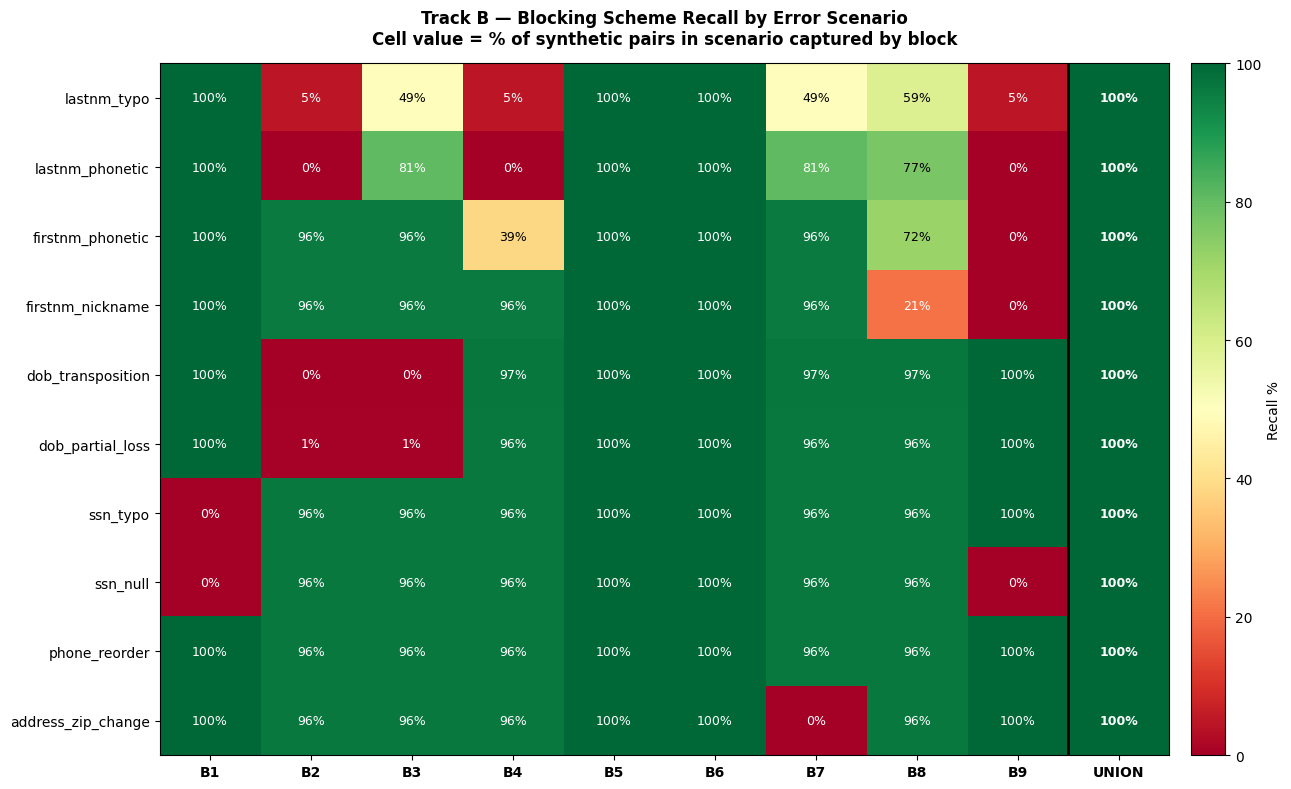

✓ Heatmap saved: track_b_recall_heatmap.png



In [13]:
print("── Building recall heatmap visualization ───────────────────────────")
 
heatmap_data = recall_matrix.set_index("scenario")[
    [f"recall_{b}" for b in block_ids] + ["cumulative_recall"]
]
heatmap_data.columns = block_ids + ["UNION"]
 
fig, ax = plt.subplots(figsize=(13, 8))
im = ax.imshow(heatmap_data.values, cmap="RdYlGn", vmin=0, vmax=100,
               aspect="auto")
 
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, fontweight="bold")
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title(
    "Track B — Blocking Scheme Recall by Error Scenario\n"
    "Cell value = % of synthetic pairs in scenario captured by block",
    fontsize=12, fontweight="bold", pad=14
)
 
# Annotate each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.iloc[i, j]
        color  = "white" if val < 30 or val > 80 else "black"
        weight = "bold"  if heatmap_data.columns[j] == "UNION" else "normal"
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                color=color, fontsize=9, fontweight=weight)
 
# Highlight UNION column with a thicker border
ax.axvline(x=len(block_ids) - 0.5, color="black", linewidth=2)
 
plt.colorbar(im, label="Recall %", fraction=0.04, pad=0.02)
plt.tight_layout()
plt.savefig("track_b_recall_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Heatmap saved: track_b_recall_heatmap.png\n")
 

## Cell 10 - HTML Report

In [14]:
run_timestamp = datetime.now().strftime("%B %d, %Y at %H:%M")
 
def _scenario_verdict(cumulative_recall):
    if cumulative_recall >= PASS_THRESHOLD:
        return "✅ PASS", "verdict-pass"
    elif cumulative_recall >= 85:
        return "⚠️  REVIEW", "verdict-warn"
    else:
        return "🔴 GAP", "verdict-fail"
 
n_pass  = sum(1 for _, r in recall_matrix.iterrows()
              if r["cumulative_recall"] >= PASS_THRESHOLD)
n_total = len(recall_matrix)
 
scenario_rows_html = ""
for _, r in recall_matrix.iterrows():
    verdict, verdict_class = _scenario_verdict(r["cumulative_recall"])
 
    block_recalls = {b: r[f"recall_{b}"] for b in block_ids}
    best_block    = max(block_recalls, key=block_recalls.get)
    best_recall   = block_recalls[best_block]
 
    scenario_rows_html += f"""
    <tr>
      <td><strong>{r['scenario']}</strong><br>
          <small style="color:#666">{r['description']}</small></td>
      <td class="num">{r['n_pairs']:,}</td>
      <td class="num strong">{r['cumulative_recall']:.1f}%</td>
      <td>{best_block} ({best_recall:.0f}%)</td>
      <td class="{verdict_class}">{verdict}</td>
    </tr>"""
 
html = f"""<!DOCTYPE html>
<html lang="en">
<head><meta charset="UTF-8"><title>Track B Recall Testing Report</title>
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; font-size: 11px;
         color: #1a1a2e; background: #f8f9fa; padding: 20px; margin: 0; }}
  .page {{ background: white; max-width: 1280px; margin: 0 auto;
          padding: 28px 32px; box-shadow: 0 2px 12px rgba(0,0,0,0.1);
          border-radius: 6px; }}
  .header {{ display: flex; justify-content: space-between;
            border-bottom: 3px solid #2E86AB; padding-bottom: 14px;
            margin-bottom: 20px; }}
  .header h1 {{ font-size: 18px; }}
  .header h2 {{ font-size: 12px; color: #2E86AB; margin-top: 3px; }}
  .header-right {{ text-align: right; font-size: 10px; color: #666;
                  line-height: 1.6; }}
  .badge {{ background: #2E86AB; color: white; padding: 3px 10px;
           border-radius: 12px; font-size: 10px; font-weight: 600;
           display: inline-block; margin-bottom: 4px; }}
  .summary-stats {{ display: grid; grid-template-columns: repeat(4, 1fr);
                   gap: 12px; margin-bottom: 18px; }}
  .stat-card {{ background: #f0f7fb; border-left: 4px solid #2E86AB;
               padding: 10px 14px; border-radius: 4px; }}
  .stat-card h3 {{ font-size: 9px; color: #2E86AB; font-weight: 700;
                  text-transform: uppercase; letter-spacing: 0.5px;
                  margin-bottom: 4px; }}
  .stat-card .stat-value {{ font-size: 18px; font-weight: 700; }}
  .stat-card .stat-context {{ font-size: 9px; color: #666; margin-top: 2px; }}
  table {{ width: 100%; border-collapse: collapse; font-size: 11px; }}
  th {{ background: #1a1a2e; color: white; padding: 9px 12px;
        text-align: left; font-size: 10px; }}
  td {{ padding: 9px 12px; border-bottom: 1px solid #eee;
        vertical-align: top; }}
  tr:nth-child(even) td {{ background: #fafbfc; }}
  .num {{ text-align: right; font-variant-numeric: tabular-nums; }}
  .strong {{ font-weight: 700; color: #2E86AB; }}
  .verdict-pass {{ color: #27ae60; font-weight: 700; }}
  .verdict-warn {{ color: #e67e22; font-weight: 700; }}
  .verdict-fail {{ color: #c0392b; font-weight: 700; }}
  .footer {{ margin-top: 18px; border-top: 1px solid #ddd;
            padding-top: 10px; display: flex;
            justify-content: space-between; color: #999; font-size: 9px; }}
</style></head>
<body>
<div class="page">
  <div class="header">
    <div>
      <h1>Track B — Synthetic Pair Recall Testing</h1>
      <h2>eMPI Blocking Scheme Feasibility Assessment</h2>
    </div>
    <div class="header-right">
      <div class="badge">INTERNAL — DRAFT</div><br>
      Generated: {run_timestamp}<br>
      Anchor records: {len(anchors):,}<br>
      Synthetic pairs: {len(synthetic_pairs_df):,}<br>
      Pass threshold: ≥{PASS_THRESHOLD}% cumulative recall
    </div>
  </div>
 
  <div class="summary-stats">
    <div class="stat-card">
      <h3>Scenarios Tested</h3>
      <div class="stat-value">{n_total}</div>
      <div class="stat-context">Error patterns simulated</div>
    </div>
    <div class="stat-card">
      <h3>Scenarios Passing</h3>
      <div class="stat-value">{n_pass} / {n_total}</div>
      <div class="stat-context">Cumulative recall ≥ {PASS_THRESHOLD}%</div>
    </div>
    <div class="stat-card">
      <h3>Anchor Records</h3>
      <div class="stat-value">{len(anchors):,}</div>
      <div class="stat-context">High-quality records perturbed</div>
    </div>
    <div class="stat-card">
      <h3>Total Synthetic Pairs</h3>
      <div class="stat-value">{len(synthetic_pairs_df):,}</div>
      <div class="stat-context">Across all scenarios</div>
    </div>
  </div>
 
  <h3 style="margin-bottom:10px;font-size:13px">Per-Scenario Recall Summary</h3>
  <table>
    <thead>
      <tr><th>Error Scenario</th><th>Pairs</th><th>Cumulative Recall</th>
          <th>Best Single Block</th><th>Verdict</th></tr>
    </thead>
    <tbody>{scenario_rows_html}</tbody>
  </table>
 
  <div class="footer">
    <span>eMPI Capstone — AllianceChicago | Methodology Evidence Base</span>
    <span>Track B Owner: Lead Analyst | Generated: {run_timestamp}</span>
  </div>
</div>
</body>
</html>"""
 
with open("track_b_recall_report.html", "w", encoding="utf-8") as f:
    f.write(html)
 
print("✅ Track B Recall Testing Complete")
print(f"   ✓ Recall matrix: track_b_recall_matrix.csv")
print(f"   ✓ Heatmap:       track_b_recall_heatmap.png")
print(f"   ✓ HTML report:   track_b_recall_report.html")
print(f"\n   Scenarios passing ≥{PASS_THRESHOLD}% threshold: {n_pass}/{n_total}")
 
if n_pass < n_total:
    failing = recall_matrix[recall_matrix["cumulative_recall"] < PASS_THRESHOLD]
    print(f"\n   🔴 SCENARIOS REQUIRING ATTENTION:")
    for _, r in failing.iterrows():
        print(f"      {r['scenario']}: {r['cumulative_recall']:.1f}% "
              f"cumulative recall")
    print(f"\n   Review these scenarios — they indicate recall gaps")
    print(f"   that may require additional blocking schemes or design changes.")
else:
    print(f"\n   ✅ All scenarios pass — blocking scheme covers known "
          f"error space.")
 

✅ Track B Recall Testing Complete
   ✓ Recall matrix: track_b_recall_matrix.csv
   ✓ Heatmap:       track_b_recall_heatmap.png
   ✓ HTML report:   track_b_recall_report.html

   Scenarios passing ≥95.0% threshold: 10/10

   ✅ All scenarios pass — blocking scheme covers known error space.
